原始长度: 640000, 新长度: 50000, 新采样率: 5000 Hz
识别到的 LA2 (外圈) 源索引: 2, 得分: 0.1764
识别到的 LA3 (滚动体) 源索引: 1, 得分: 0.2799


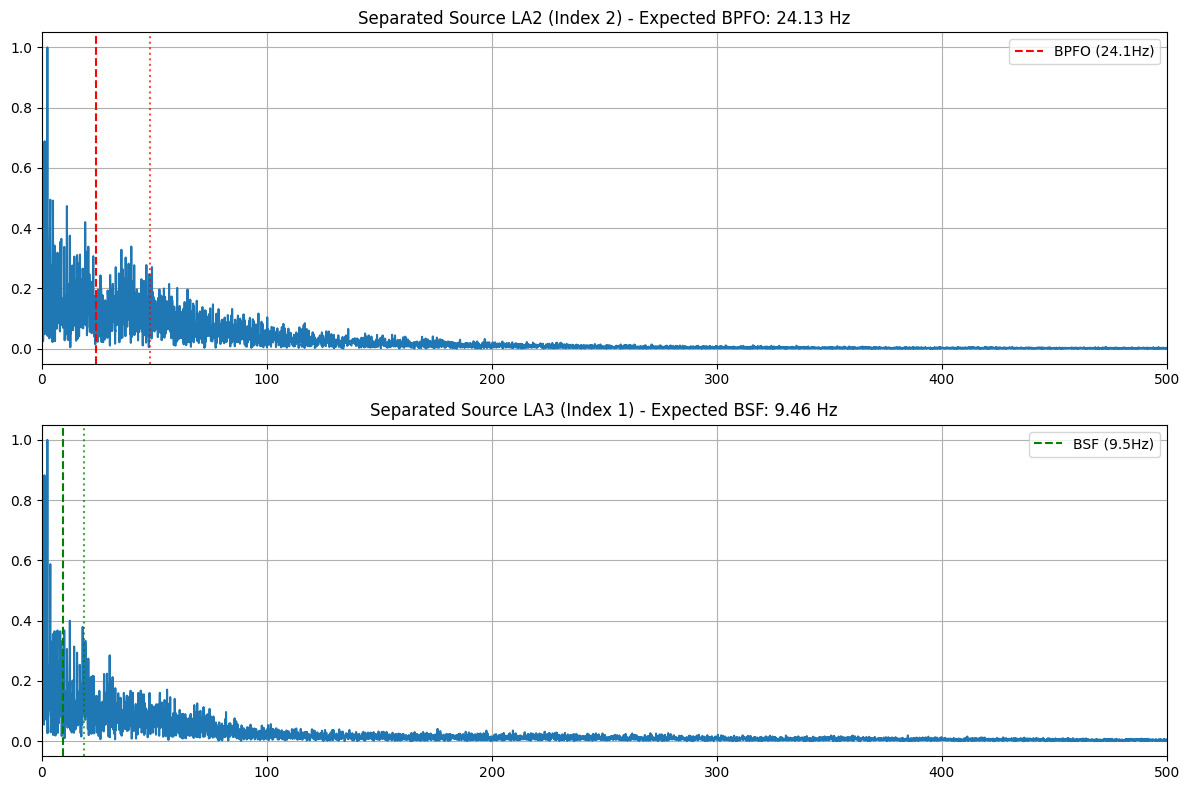

In [12]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, decimate
from sklearn.decomposition import FastICA
from scipy.signal import hilbert
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt
# 1. 加载数据
file_path = 'data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_0kN.csv'
df = pd.read_csv(file_path)
signal_raw = df['CH17'].values

# 2. 参数定义 (基于文档)
fs_original = 64000  # 原始采样率 64kHz
fr = 2.99            # 转频 20Hz
# 理论故障频率
f_bpfo = 8.071 * fr  # LA2: 161.42 Hz
f_bsf = 3.164 * fr   # LA3: 63.28 Hz

# 3. 降采样 (关键步骤)
# 设计低通滤波器，截止频率 2000Hz
cutoff = 2000
nyq = 0.5 * fs_original
normal_cutoff = cutoff / nyq
b, a = butter(4, normal_cutoff, btype='low', analog=False)
signal_filtered = filtfilt(b, a, signal_raw)

# 降采样至 5000Hz (降采样因子 12.8 -> 取整为13或分步降采样，这里简化为直接decimate)
# 为了精确，分步或直接重采样，此处使用decimate (默认抗混叠滤波)
down_factor = int(fs_original / 5000) # 12.8 -> 12? 建议用resample更准，这里演示用decimate取整
# 更推荐直接使用 scipy.signal.resample 保证点数
from scipy.signal import resample
fs_new = 5000
num_samples = int(len(signal_filtered) * fs_new / fs_original)
signal = resample(signal_filtered, num_samples)

print(f"原始长度: {len(signal_raw)}, 新长度: {len(signal)}, 新采样率: {fs_new} Hz")

# 4. 虚拟多通道构造 (VMD 模拟)
# 实际使用时请替换为真实的 VMD 实现 (如 vmdpy)
# 这里假设 decompose_vmd 返回 shape (K, N) 的矩阵
def dummy_vmd(sig, K=5):
    # 伪代码：实际需调用 VMD 算法
    # 为了演示，使用 EMD 或 小波 代替，或者返回随机占位
    # 强烈建议集成 pyvmd 或 vmdpy
    from PyEMD import EMD
    emd = EMD()
    imfs = emd(sig, max_imf=K)
    # 补齐长度以防不一致
    min_len = min([len(c) for c in imfs])
    return np.array([c[:min_len] for c in imfs])

# 执行分解 (假设 K=5: 2个故障 + 1个转频 + 2个噪声)
K = 5
imfs = dummy_vmd(signal, K=K) 
# imfs shape: (K, N)

# 5. 盲源分离 (FastICA)
ica = FastICA(n_components=K, random_state=42, max_iter=1000)
# 输入需要 (N, K)
sources = ica.fit_transform(imfs.T) 
sources = sources.T # 转回 (K, N)

# 6. 筛选与诊断
def get_envelope_spectrum(sig, fs):
    analytic = hilbert(sig)
    env = np.abs(analytic) - np.mean(np.abs(analytic))
    freqs = rfftfreq(len(env), 1/fs)
    spec = np.abs(rfft(env))
    return freqs, spec / np.max(spec)

# 计算每个独立源在目标频率处的能量得分
scores_bpfo = []
scores_bsf = []

for s in sources:
    freqs, spec = get_envelope_spectrum(s, fs_new)
    # 寻找最近频率点的幅值
    idx_bpfo = np.argmin(np.abs(freqs - f_bpfo))
    idx_bsf = np.argmin(np.abs(freqs - f_bsf))
    
    # 简单评分：目标频率幅值 + 2倍频幅值
    score_bpfo = spec[idx_bpfo] + 0.5 * spec[np.argmin(np.abs(freqs - 2*f_bpfo))]
    score_bsf = spec[idx_bsf] + 0.5 * spec[np.argmin(np.abs(freqs - 2*f_bsf))]
    
    scores_bpfo.append(score_bpfo)
    scores_bsf.append(score_bsf)

scores_bpfo = np.array(scores_bpfo)
scores_bsf = np.array(scores_bsf)

# 选出 LA2 (BPFO) 最明显的源
la2_source_idx = np.argmax(scores_bpfo)
# 选出 LA3 (BSF) 最明显的源 (排除已选中的，防止重复)
temp_scores_bsf = scores_bsf.copy()
temp_scores_bsf[la2_source_idx] = -1
la3_source_idx = np.argmax(temp_scores_bsf)

print(f"识别到的 LA2 (外圈) 源索引: {la2_source_idx}, 得分: {scores_bpfo[la2_source_idx]:.4f}")
print(f"识别到的 LA3 (滚动体) 源索引: {la3_source_idx}, 得分: {scores_bsf[la3_source_idx]:.4f}")

# 7. 绘图验证
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# 绘制 LA2 源的包络谱
freqs, spec = get_envelope_spectrum(sources[la2_source_idx], fs_new)
axs[0].plot(freqs, spec)
axs[0].set_title(f"Separated Source LA2 (Index {la2_source_idx}) - Expected BPFO: {f_bpfo:.2f} Hz")
axs[0].axvline(f_bpfo, color='r', linestyle='--', label=f'BPFO ({f_bpfo:.1f}Hz)')
axs[0].axvline(2*f_bpfo, color='r', linestyle=':', alpha=0.7)
axs[0].set_xlim(0, 500)
axs[0].legend()
axs[0].grid(True)

# 绘制 LA3 源的包络谱
freqs, spec = get_envelope_spectrum(sources[la3_source_idx], fs_new)
axs[1].plot(freqs, spec)
axs[1].set_title(f"Separated Source LA3 (Index {la3_source_idx}) - Expected BSF: {f_bsf:.2f} Hz")
axs[1].axvline(f_bsf, color='g', linestyle='--', label=f'BSF ({f_bsf:.1f}Hz)')
axs[1].axvline(2*f_bsf, color='g', linestyle=':', alpha=0.7)
axs[1].set_xlim(0, 500)
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()